# Multi-Anchor Spatial ResNet Object Detector (Stage 7)

Trains `ObjectDetectorResNet` with a multi-anchor grid spatial head ($S \times S \times K$) to predict bounding boxes and character classes.
Each spatial cell predicts $K=3$ anchor slots `[x, y, w, h, conf]`, using **Focal Loss** for objectness confidence and Aligned IoU loss for localization.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` ($K=3$) → `DetectionLoss` (Focal Loss) → `fit()`


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import get_detection_loaders, S, K
from generator.dataset import EMNIST_CLASS_NAMES
from utils.trainer import fit, evaluate_detection, evaluate_detection_sweep
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
GRID_SIZE   = S        # 14x14 grid
CONF_THRESH = 0.5     # sigmoid threshold at inference
MODEL_SIZE  = 'n'
CLASS_NAMES = EMNIST_CLASS_NAMES['bymerge']
NUM_ANCHORS = K
USE_FOCAL_LOSS = True
FOCAL_ALPHA    = 0.25
FOCAL_GAMMA    = 2.0
USE_POS_WEIGHT = False

print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')
print(f'Grid Size: {GRID_SIZE}x{GRID_SIZE}')


Device   : cuda
PyTorch  : 2.11.0+cu130
Grid Size: 14x14


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, targets, labels = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT grid targets   : {targets.shape}')  # (B, S, S, 5)
print(f'GT grid labels    : {labels.shape}')   # (B, S, S)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Image batch shape : torch.Size([198, 1, 224, 224])
GT grid targets   : torch.Size([198, 14, 14, 1, 5])
GT grid labels    : torch.Size([198, 14, 14, 1])
Train batches: 1213 | Val batches: 76


## 2 · Model Architecture


In [3]:
model = get_detector(size=MODEL_SIZE).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, S, S, 5 + num_classes)


Parameters: 392,788
Output shape: torch.Size([198, 14, 14, 1, 52])


## 3 · Loss Function, Optimiser & Scheduler


In [4]:
criterion = DetectionLoss(
    lambda_conf    = 1.0,
    lambda_class   = 1.0,
    lambda_iou     = 1.0,
    use_focal_loss = USE_FOCAL_LOSS,
    focal_alpha    = FOCAL_ALPHA,
    focal_gamma    = FOCAL_GAMMA,
    use_pos_weight = USE_POS_WEIGHT,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = f"{NUM_ANCHORS}_grid_detector_{MODEL_SIZE}"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_f1
)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

print(f'Criterion : {type(criterion).__name__}')
print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')


Criterion : DetectionLoss
Optimizer : AdamW
Scheduler : OneCycleLR


## 4 · Training


In [5]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run '1_grid_detector_n_20260816_102736' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\1_grid_detector_n_20260816_102736.json'
Resuming training from epoch 1
Batch  1 | data=864.6ms pad=1.0ms forward=160.4ms loss=178.3ms backward=293.1ms step=112.6ms
Batch  2 | data=0.1ms pad=0.8ms forward=8.8ms loss=2.3ms backward=24.4ms step=2.9ms
Batch  3 | data=0.2ms pad=0.8ms forward=8.7ms loss=2.2ms backward=23.2ms step=2.7ms
Batch  4 | data=0.2ms pad=0.8ms forward=8.8ms loss=2.6ms backward=23.5ms step=2.5ms
Batch  5 | data=0.1ms pad=0.8ms forward=8.7ms loss=3.0ms backward=24.0ms step=4.0ms
Train: 97.9s | Val: 48.5s
  --> Det  | PR: 0.169 | Rec: 0.130 | F1: 0.147 | TP: 15542 FP: 76500 FN: 104363
  --> Cls  | Acc: 0.377
  --> E2E  | F1: 0.055 | PR: 0.064 | Rec: 0.049
[RunLogger] Epoch   2 | train_loss=18.4277  val_loss=11.2282  val_f1=0.0554%  lr=6.90e-05  ⏱ 97.9s  ★ NEW BEST
Batch  1 | data=809.1ms pad=0.9ms forward=12.7ms

## 5 · Training Dashboard & Curves


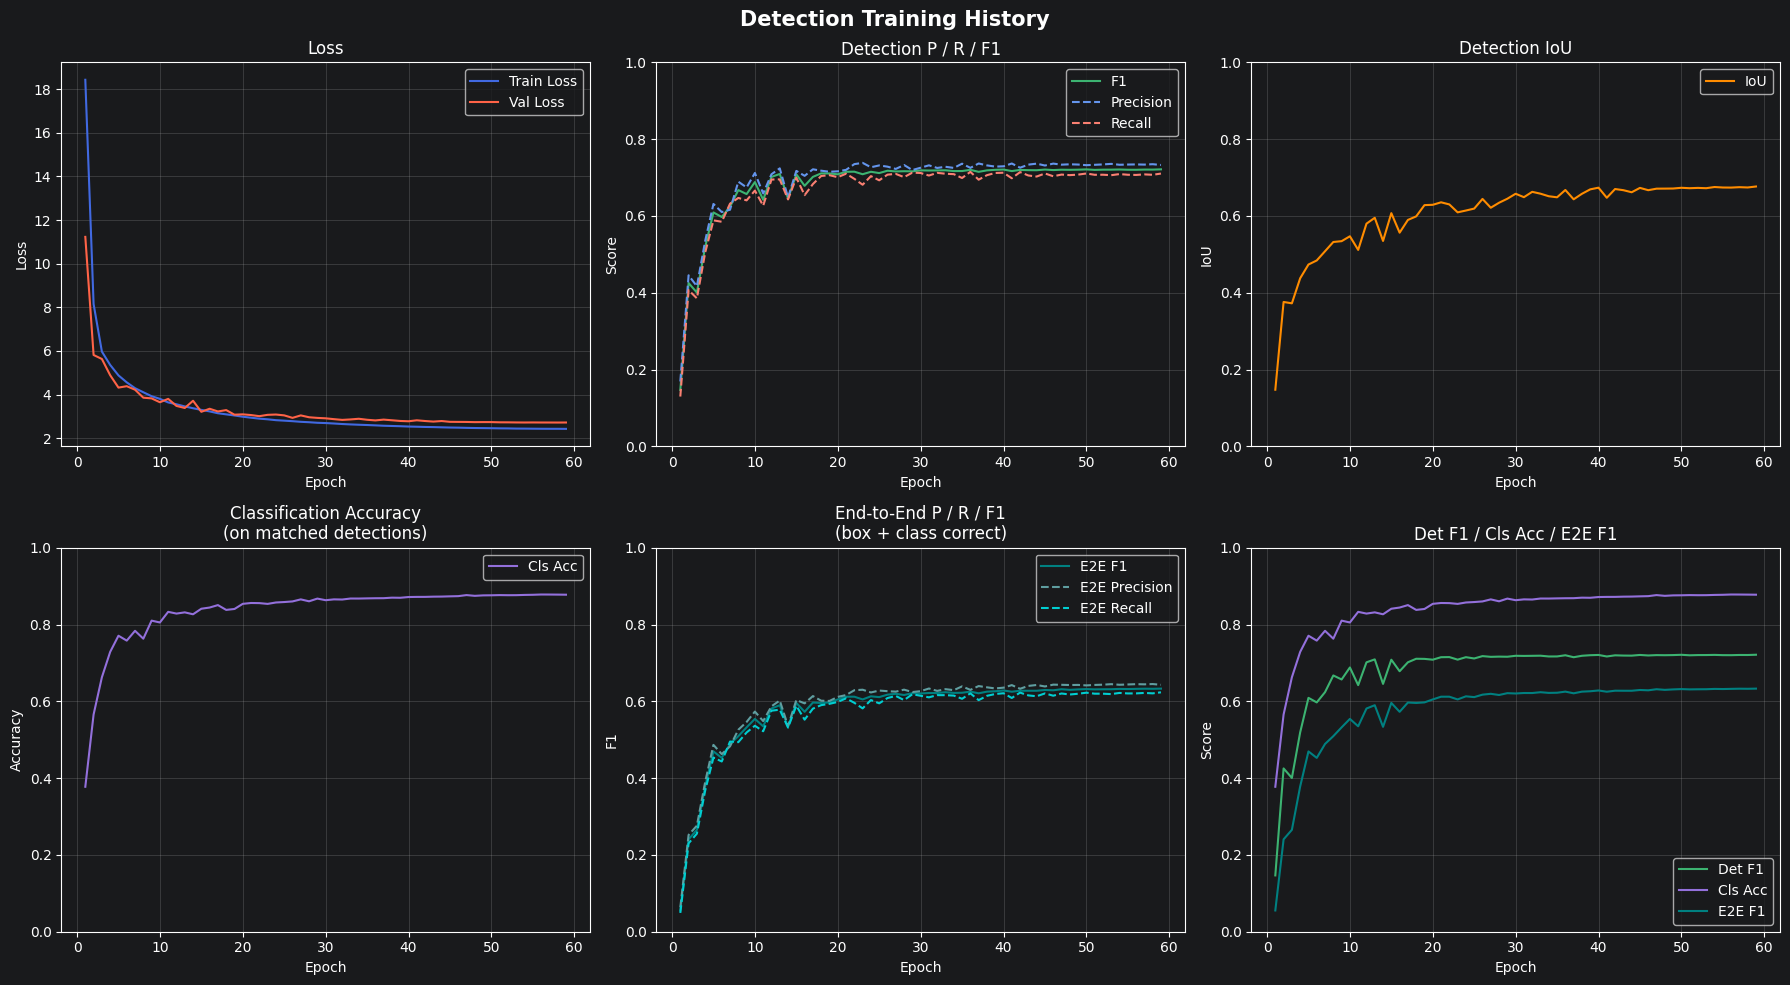

In [6]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 6 · Final Evaluation on Test Set


In [7]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 2.7016
  IoU      : 0.6792
  Precision: 0.7370
  Recall   : 0.7154
  F1       : 0.7260
  TP/FP/FN : 257960 / 92065 / 102607

=== Classification (on matched detections) ===
  Accuracy : 0.8743
  Per-class:
    [0] class_0: acc=0.6760  e2e_p=0.5001  e2e_r=0.5142  e2e_f1=0.5071
    [1] class_1: acc=0.6913  e2e_p=0.4062  e2e_r=0.5139  e2e_f1=0.4537
    [2] class_2: acc=0.8884  e2e_p=0.7079  e2e_r=0.6827  e2e_f1=0.6951
    [3] class_3: acc=0.9714  e2e_p=0.7689  e2e_r=0.7351  e2e_f1=0.7517
    [4] class_4: acc=0.9131  e2e_p=0.7358  e2e_r=0.6989  e2e_f1=0.7169
    [5] class_5: acc=0.8784  e2e_p=0.7120  e2e_r=0.6738  e2e_f1=0.6924
    [6] class_6: acc=0.9112  e2e_p=0.7224  e2e_r=0.6928  e2e_f1=0.7073
    [7] class_7: acc=0.9708  e2e_p=0.7360  e2e_r=0.7281  e2e_f1=0.7320
    [8] class_8: acc=0.9332  e2e_p=0.7100  e2e_r=0.7028  e2e_f1=0.7064
    [9] class_9: acc=0.8171  e2e_p=0.5165  e2e_r=0.6151  e2e_f1=0.5615
    [10] class_10: acc=0.9572  e2e_p=0.

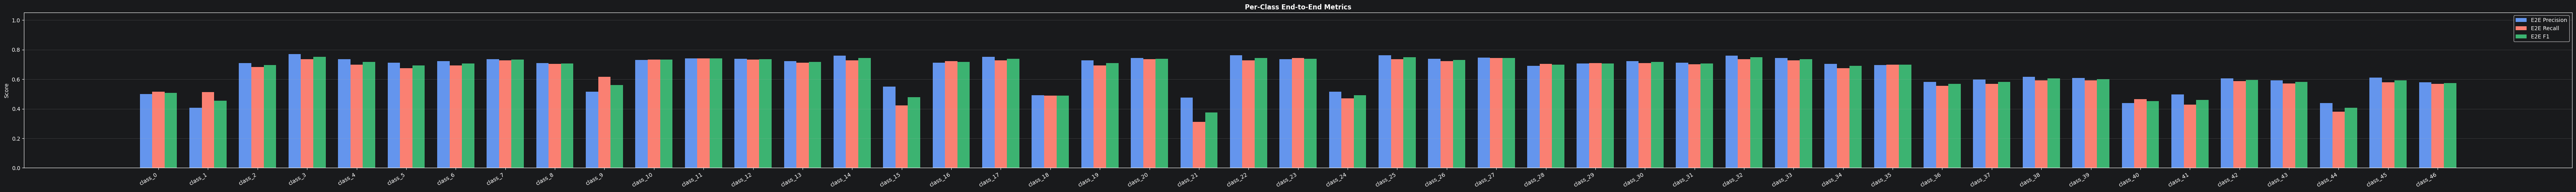

In [8]:
Visualizer.visualize_per_class_e2e(metrics)

## 7 · Prediction Visualisation

- **Lime** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH` (plus NMS)


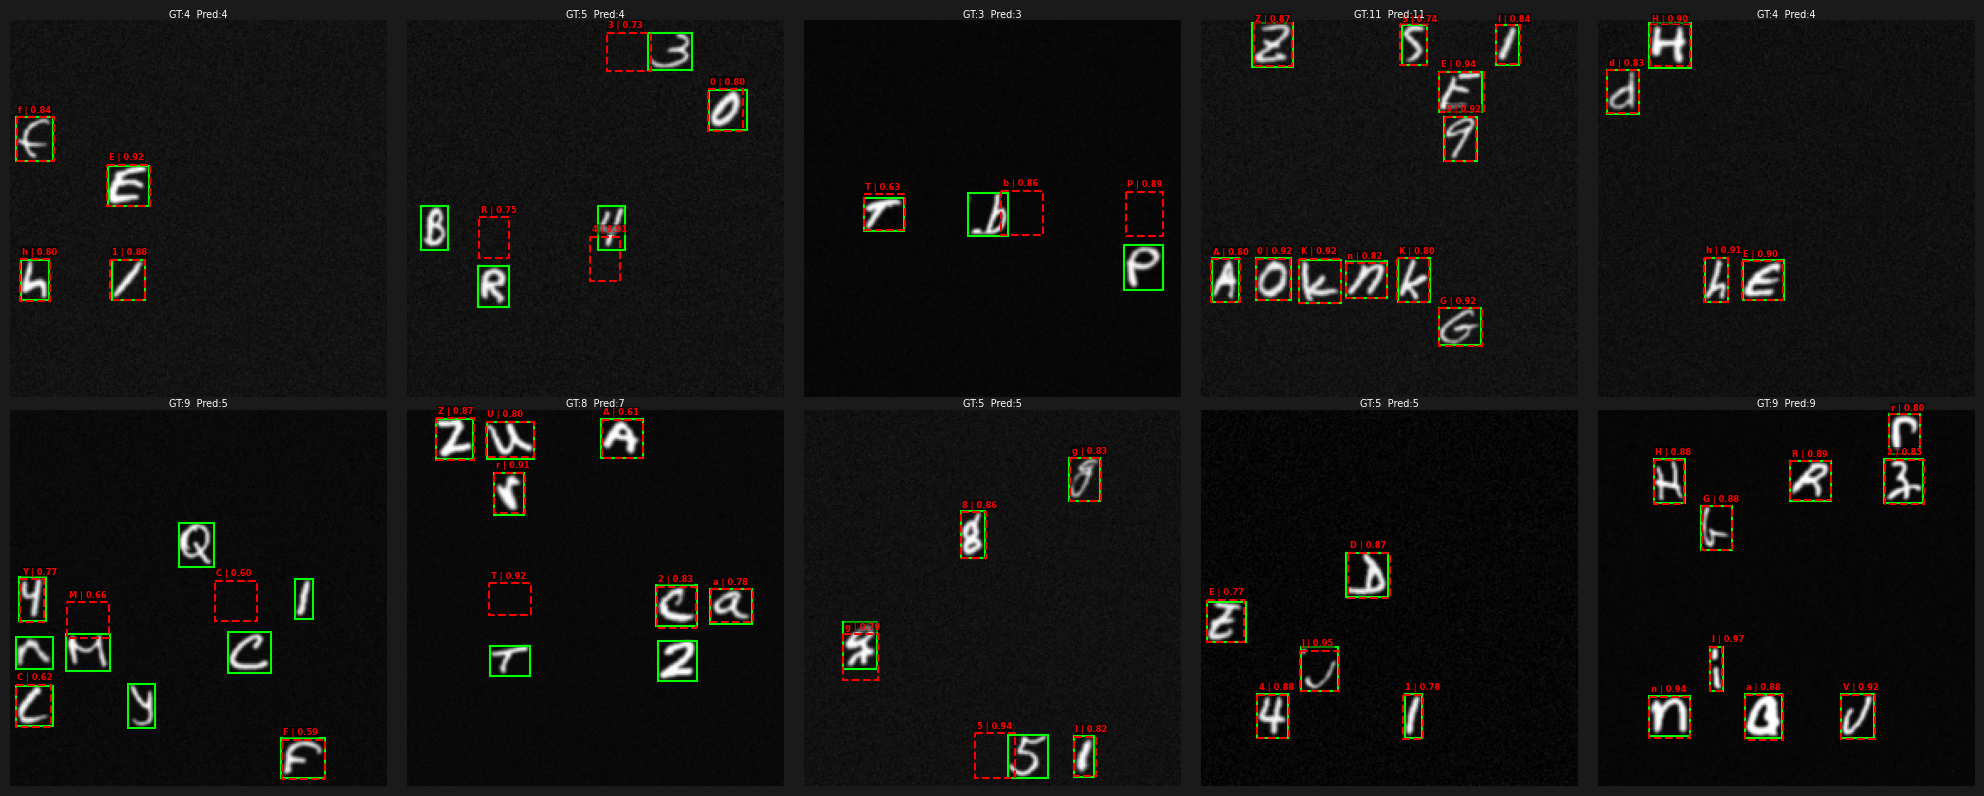

In [9]:
test_batch = next(iter(test_loader))
imgs_t, targets_t, labels_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()

Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    gt_grid=targets_t,
    conf_thresh=CONF_THRESH,
    class_names=CLASS_NAMES,
)


## 8 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to evaluate the full Precision / Recall / F1 trade-off.


In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    conf_thresholds=np.arange(0.1, 0.95, 0.05),
    iou_threshold=0.5,
    print_table=True,
)

if 'logger' in locals() and logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1   ClsAcc       TP       FP       FN
------------------------------------------------------------------
  0.10  0.6228  0.7487  0.6800   0.8725   269949   163503    90618
  0.15  0.6533  0.7451  0.6962   0.8728   268653   142558    91914
  0.20  0.6726  0.7419  0.7055   0.8731   267503   130230    93064
  0.25  0.6869  0.7391  0.7120   0.8733   266500   121476    94067
  0.30  0.7000  0.7363  0.7177   0.8735   265497   113779    95070
  0.35  0.7119  0.7331  0.7223   0.8737   264326   106988    96241
  0.40  0.7218  0.7288  0.7253   0.8740   262788   101270    97779
  0.45  0.7301  0.7234  0.7268   0.8741   260844    96420    99723
  0.50  0.7370  0.7154  0.7260   0.8743   257960    92065   102607
  0.55  0.7428  0.7059  0.7239   0.8745   254532    88133   106035
  0.60  0.7486  0.6932  0.7199   0.8747   249942    83915   110625
  0.65  0.7554  0.6772  0.7141   0.8751   244166    79077   116401
  0.70  0.7640  0.6540  0.7047   0.8757   235793    72844   1

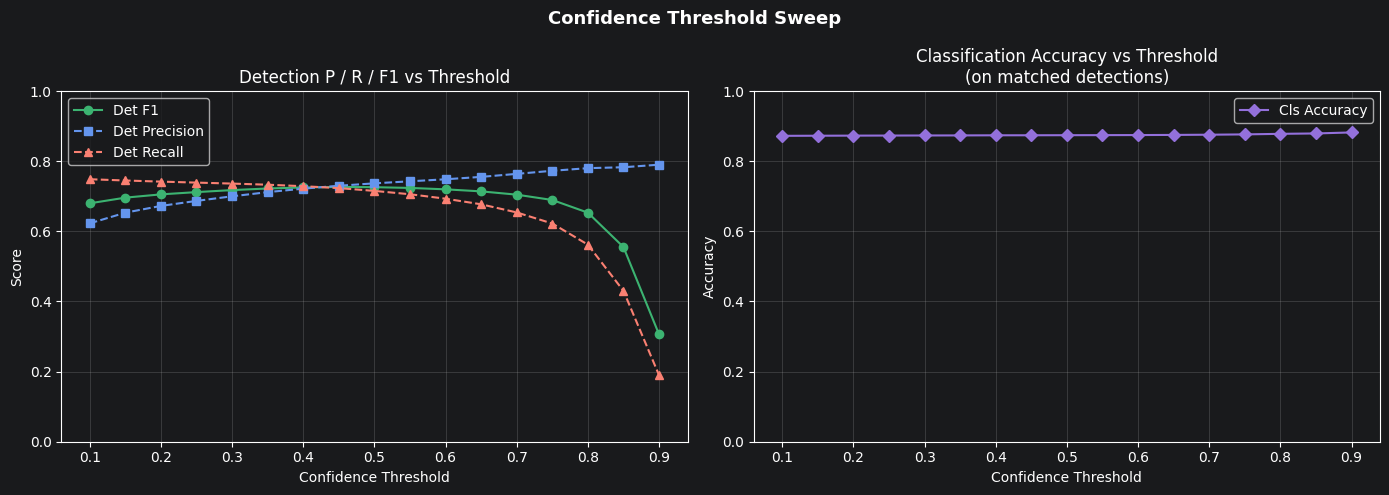


Best conf threshold : 0.45
  Det  F1  = 0.7268
  Cls  Acc = 0.8741
Per-class E2E F1:
  [0] class_0: e2e_f1=0.5065  e2e_p=0.4956  e2e_r=0.5178
  [1] class_1: e2e_f1=0.4532  e2e_p=0.4017  e2e_r=0.5198
  [2] class_2: e2e_f1=0.6943  e2e_p=0.7015  e2e_r=0.6873
  [3] class_3: e2e_f1=0.7530  e2e_p=0.7609  e2e_r=0.7452
  [4] class_4: e2e_f1=0.7177  e2e_p=0.7302  e2e_r=0.7057
  [5] class_5: e2e_f1=0.6927  e2e_p=0.7058  e2e_r=0.6800
  [6] class_6: e2e_f1=0.7078  e2e_p=0.7164  e2e_r=0.6994
  [7] class_7: e2e_f1=0.7325  e2e_p=0.7283  e2e_r=0.7368
  [8] class_8: e2e_f1=0.7084  e2e_p=0.7052  e2e_r=0.7116
  [9] class_9: e2e_f1=0.5605  e2e_p=0.5111  e2e_r=0.6205
  [10] class_10: e2e_f1=0.7321  e2e_p=0.7231  e2e_r=0.7414
  [11] class_11: e2e_f1=0.7415  e2e_p=0.7344  e2e_r=0.7489
  [12] class_12: e2e_f1=0.7342  e2e_p=0.7304  e2e_r=0.7380
  [13] class_13: e2e_f1=0.7175  e2e_p=0.7160  e2e_r=0.7190
  [14] class_14: e2e_f1=0.7442  e2e_p=0.7535  e2e_r=0.7350
  [15] class_15: e2e_f1=0.4779  e2e_p=0.5438  e2e

In [11]:
# Plot Det P/R/F1 and Cls Accuracy across thresholds
Visualizer.visualize_sweep_results(sweep_results)

# Per-class E2E F1 at best Det-F1 threshold
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest conf threshold : {best_r['conf']:.2f}")
print(f"  Det  F1  = {best_r['f1']:.4f}")
print(f"  Cls  Acc = {best_r['cls_accuracy']:.4f}")
print('Per-class E2E F1:')
for k, v in best_r['per_class_e2e'].items():
    name = v.get('name', f'class_{k}')
    print(f"  [{k}] {name}: e2e_f1={v['e2e_f1']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}")
